> # ⚠️ CUADERNO OBSOLETO — catálogo v1
>
> Este cuaderno analiza el **catálogo v1** (`logs/eval_catalogo`, 288 escenarios × 10 réplicas,
> batería 100), retirado en la sesión 6 y sustituido por el **v2** y después por el **v3**.
> **Ninguna de sus cifras debe presentarse como resultado del trabajo.**
>
> El análisis vigente es **`analisis/evaluacion_final.ipynb`**, sobre el catálogo v3
> (`logs/eval_catalogo_v3`, 360 escenarios × 3 réplicas, batería 40).
>
> Se conserva por dos motivos:
> 1. Es la única versión ejecutable de las **cuatro refutaciones** (`eval_b4`, `eval_d8`,
>    `eval_hc`, `eval_rounds`) y de la **ablación del canal de comunicación** (`eval_c1_*`),
>    que no se han vuelto a medir sobre el v3 (duda **D-13**).
> 2. La comparación v1 ↔ v3 es la **lección metodológica** del capítulo 6: el mismo código da
>    conclusiones opuestas según la composición del catálogo.
>
> Sus ocho figuras son `analisis/figuras/01_*` … `08_*`; las del análisis vigente son
> `p1_*`, `p2_*` y `p3_*`.

# Evaluación final — DEC-MRTAU

**TFM: Asignación distribuida de tareas multi-robot bajo incertidumbre.** Manuel Olías.

Este cuaderno evalúa cinco políticas de asignación distribuida sobre el catálogo definitivo de
escenarios y responde a tres preguntas:

1. **¿Bajo qué condiciones funciona Dec-MCTS?** ¿Hay algún régimen en el que supere a las subastas?
2. **¿Bajo qué condiciones falla, y por qué mecanismo concreto?**
3. **¿Esa incapacidad es un defecto de implementación o una limitación del planteamiento?**

La respuesta corta, que el resto del cuaderno documenta: Dec-MCTS **iguala a CBBA cuando los
planes son predecibles** y es, junto a CBBA, el único método que convierte robots adicionales en
rendimiento; **pierde bajo incertidumbre**, y la brecha **crece con el tamaño del equipo**. El
mecanismo es un **exceso de deconflicción** —cede tareas a vecinos cuyos planes comunicados ya no
son válidos— y **cuatro intervenciones independientes sobre la implementación no lo corrigen**
(dos de ellas con potencia estadística suficiente para descartarlo), lo que sitúa la limitación
en el planteamiento y no en el código.

---

### Datos

| Tanda | Contenido | Uso en este cuaderno |
|---|---|---|
| `eval_catalogo` | 288 escenarios × 5 solvers × 10 réplicas = 14 400 ejecuciones | Análisis principal |
| `eval_c1_1E`, `eval_c1_mix` | Ablación del canal de comunicación | §6 |
| `eval_hc` | Alto cómputo (×40 iteraciones) | §6 |
| `eval_rounds` | Rondas de comunicación (×30) | §6 |
| `eval_b4`, `eval_d8` | Intentos de corrección B4 y D-08 | §6 |
| `eval_bundles` | Catálogo antiguo | §6 (referencia de cómputo normal) |

Los datos se generan con:

```bash
python3 scripts/extract_metrics.py logs/eval_catalogo logs/eval_b4 logs/eval_d8 \
        logs/eval_hc logs/eval_rounds logs/eval_c1_1E logs/eval_c1_mix logs/eval_bundles \
        -o analisis/resultados.csv
```

**Métrica principal**: `final_reward` = fracción de tareas completadas (`reward00` con $k_1=1$).

**Unidad de análisis**: el **escenario** (media de sus réplicas). Las comparaciones entre solvers
son **pareadas por escenario** y el error estándar se calcula **entre escenarios**, no entre
réplicas — la variación entre instancias de una misma celda (±0.15) es un orden de magnitud
mayor que el ruido entre réplicas (±0.016).

## 0 · Preparación

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from pathlib import Path

RUTA = Path('resultados.csv') if Path('resultados.csv').exists() else Path('analisis/resultados.csv')
FIGS = RUTA.parent / 'figuras'; FIGS.mkdir(exist_ok=True)

# ── Paleta (validada para daltonismo: CVD ΔE 9.2, visión normal 16.3, all-pairs) ──
INK, INK2, MUTED   = '#0b0b0b', '#52514e', '#898781'
GRID, AXIS, SURFACE = '#e1e0d9', '#c3c2b7', '#fcfcfb'
NEG, POS, MID       = '#e34948', '#2a78d6', '#f0efec'   # diverging: rojo ↔ azul
COLOR = {'cbba': '#2a78d6', 'dec-mcts-v4-g9999': '#eb6834',
         'cbaa': '#1baf7a', 'greedy': '#4a3aa7', 'random': MUTED}
NOMBRE = {'cbba': 'CBBA', 'dec-mcts-v4-g9999': 'Dec-MCTS', 'cbaa': 'CBAA',
          'greedy': 'Greedy', 'random': 'Random'}
SOLVERS = ['cbba', 'dec-mcts-v4-g9999', 'cbaa', 'greedy', 'random']
DEC, REF = 'dec-mcts-v4-g9999', 'cbba'

mpl.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK2, 'axes.titlecolor': INK,
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.linewidth': 0.8,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.7, 'axes.axisbelow': True,
    'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'font.size': 10, 'axes.titlesize': 11, 'axes.titleweight': 'semibold',
    'legend.frameon': False, 'lines.linewidth': 2, 'lines.markersize': 6,
    'figure.dpi': 110, 'savefig.dpi': 200, 'savefig.bbox': 'tight',
})

def guardar(fig, nombre):
    """Guarda la figura en analisis/figuras/ para poder incrustarla en la memoria."""
    fig.savefig(FIGS / f'{nombre}.png'); fig.savefig(FIGS / f'{nombre}.pdf')

print(f'Paleta y estilo listos · figuras → {FIGS}')

Paleta y estilo listos · figuras → figuras


In [2]:
df = pd.read_csv(RUTA, low_memory=False)
for c in ('robots', 'tareas', 'instancia'):
    df[c] = pd.to_numeric(df[c], errors='coerce')

# ── Catálogo definitivo: una fila por (escenario, solver), promediando réplicas ──
cat = df[df.tanda == 'eval_catalogo'].copy()
cat['carga'] = cat.tareas * cat.coalicion.map({'q1': 1, 'q2': 2, 'qm': 2}) / cat.robots

FACTORES = ['bloque', 'robots', 'tareas', 'geometria', 'ventana',
            'regimen', 'coalicion', 'instancia', 'carga']
esc = (cat.groupby(['escenario'] + FACTORES + ['solver'], as_index=False)
          .agg(reward=('final_reward', 'mean'), intento=('tasa_intento', 'mean'),
               exito=('tasa_exito', 'mean'), makespan=('average_robot_makespan', 'mean'),
               distancia=('sum_robot_travel_distance', 'mean'),
               retiro=('t_retiro_medio', 'mean'), cpu=('computing_time', 'mean'),
               muertos=('failed_agents', 'mean')))

def ancho(metrica):
    """Tabla escenario × solver de una métrica, con los factores del escenario adjuntos."""
    w = esc.pivot(index='escenario', columns='solver', values=metrica)
    return w.join(esc.drop_duplicates('escenario').set_index('escenario')[FACTORES])

W = ancho('reward'); W['delta'] = W[DEC] - W[REF]
WI = ancho('intento'); WE = ancho('exito')

def resumen(d, col='delta'):
    """Media, error estándar entre escenarios, n y nº de victorias."""
    x = d[col].dropna()
    return pd.Series({'media': x.mean(), 'ee': x.sem(), 'n': len(x),
                      'gana': int((x > 1e-9).sum())})

# Nombre legible de familia de escenario, para los desgloses
def familia(r):
    if r.bloque == 'B': return {'A': 'ventana ancha', 'C': 'ventana escalonada'}[r.ventana]
    if r.bloque == 'C': return {'q2': 'coalición q=2', 'qm': 'coalición mixta'}[r.coalicion]
    if r.bloque == 'D': return {'rnd': 'geometría uniforme', 'asy': 'geometría asimétrica'}[r.geometria]
    if r.bloque == 'E': return f'incertidumbre {r.regimen}'
    return 'ventana estrecha'
W['familia'] = W.apply(familia, axis=1)

print(f'{len(df):,} ejecuciones · {esc.escenario.nunique()} escenarios del catálogo · '
      f'{len(SOLVERS)} solvers')

17,860 ejecuciones · 288 escenarios del catálogo · 5 solvers


## 1 · Panorama general

Primero, dónde queda cada método sobre el catálogo completo y cómo se degrada al aumentar la
incertidumbre. El gradiente de incertidumbre tiene cuatro niveles: `det` (determinista, ρ=1),
`lev` (ρ=0.9, σ=3), `est` (ρ=0.75, σ=10) y `fue` (ρ=0.5, σ=10).

In [3]:
tabla = (esc.groupby('solver').reward.agg(['mean', 'sem'])
            .reindex(SOLVERS).rename(index=NOMBRE)
            .rename(columns={'mean': 'recompensa media', 'sem': 'EE'}))
por_reg = (esc.pivot_table(index='solver', columns='regimen', values='reward')
              .reindex(SOLVERS)[['det', 'lev', 'est', 'fue']].rename(index=NOMBRE))
display(tabla.join(por_reg).round(4))

,recompensa media,EE,det,lev,est,fue
solver,,,,,,
CBBA,0.6031,0.0074,0.6663,0.6109,0.5525,0.4044
Dec-MCTS,0.5676,0.0087,0.6607,0.5817,0.4886,0.3407
CBAA,0.4730,0.0072,0.5363,0.4902,0.4212,0.2841
Greedy,0.3894,0.0082,0.4329,0.3637,0.3571,0.2461
Random,0.3314,0.0066,0.3690,0.3169,0.3032,0.2048


findfont: Failed to find font weight semibold, now using 700.


findfont: Failed to find font weight semibold, now using 700.


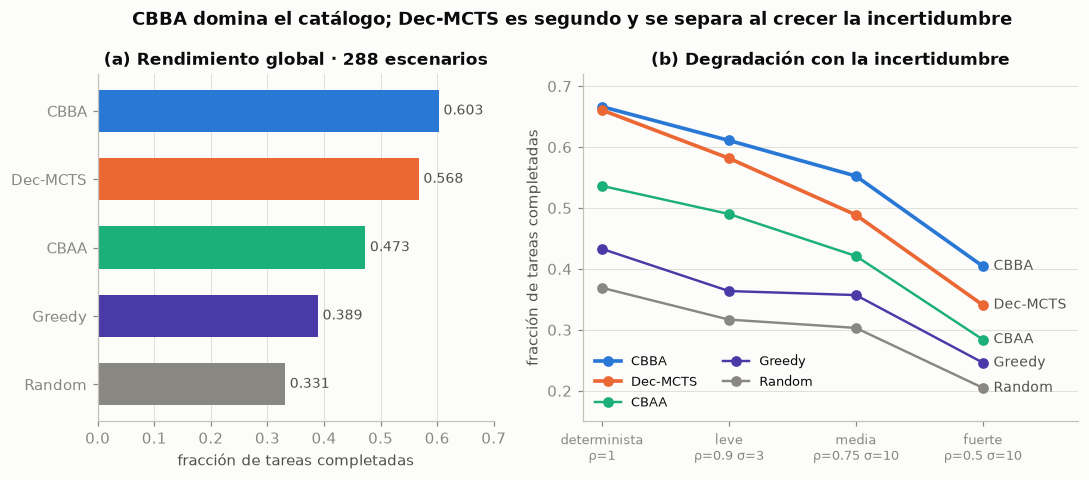

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.1),
                               gridspec_kw={'width_ratios': [1, 1.25]})

# (a) ranking global
orden = esc.groupby('solver').reward.mean().reindex(SOLVERS).sort_values()
ax1.barh(range(len(orden)), orden.values, height=0.62,
         color=[COLOR[s] for s in orden.index])
ax1.set_yticks(range(len(orden)), [NOMBRE[s] for s in orden.index])
for i, v in enumerate(orden.values):
    ax1.text(v + 0.008, i, f'{v:.3f}', va='center', fontsize=9, color=INK2)
ax1.set_xlim(0, 0.70); ax1.set_xlabel('fracción de tareas completadas')
ax1.set_title('(a) Rendimiento global · 288 escenarios')
ax1.grid(axis='y', visible=False)

# (b) degradación por régimen
regs = ['det', 'lev', 'est', 'fue']
etiq = ['determinista\nρ=1', 'leve\nρ=0.9 σ=3', 'media\nρ=0.75 σ=10', 'fuerte\nρ=0.5 σ=10']
for s in SOLVERS:
    y = [esc[(esc.solver == s) & (esc.regimen == r)].reward.mean() for r in regs]
    ax2.plot(range(4), y, marker='o', color=COLOR[s], label=NOMBRE[s],
             zorder=3 if s in (DEC, REF) else 2,
             linewidth=2.4 if s in (DEC, REF) else 1.6)
    ax2.annotate(NOMBRE[s], (3, y[3]), xytext=(7, 0), textcoords='offset points',
                 va='center', fontsize=9, color=INK2)
ax2.set_xticks(range(4), etiq, fontsize=8.5)
ax2.set_xlim(-0.15, 3.75); ax2.set_ylim(0.15, 0.72)
ax2.set_ylabel('fracción de tareas completadas')
ax2.set_title('(b) Degradación con la incertidumbre')
ax2.grid(axis='x', visible=False)
ax2.legend(loc='lower left', fontsize=8.5, ncol=2)

fig.suptitle('CBBA domina el catálogo; Dec-MCTS es segundo y se separa al crecer la incertidumbre',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, '01_panorama'); plt.show()

**Lectura.** CBBA es el mejor en los cuatro regímenes. Dec-MCTS es segundo, muy por encima de
CBAA y Greedy, pero la distancia con CBBA **se abre** al aumentar la incertidumbre: de 0.005 en
determinista a 0.063 con incertidumbre fuerte. Las dos líneas superiores se separan; las tres
inferiores mantienen su orden. Esto ya sugiere que lo que falla no es la calidad general del
método sino algo específico de la incertidumbre.

## 2 · Lo que Dec-MCTS sí consigue: escalar con el equipo

El bloque **A1** del catálogo está calibrado a **iso-dificultad**: la carga por robot se mantiene
constante (L = 6 plazas de trabajador por robot) y el horizonte es fijo, de modo que al variar el
número de robots **la dificultad del problema no cambia**. Es la única forma de leer el efecto del
tamaño del equipo sin confundirlo con el de la holgura.

Sobre ese bloque medimos cuánto rendimiento gana cada método por cada robot adicional.

In [5]:
a1 = esc[esc.bloque == 'A1']
pend = []
for s in SOLVERS:
    for reg in ('det', 'est'):
        d = a1[(a1.solver == s) & (a1.regimen == reg)]
        b, _ = np.polyfit(d.robots, d.reward, 1)
        # error estándar de la pendiente
        res = d.reward - np.polyval(np.polyfit(d.robots, d.reward, 1), d.robots)
        sb = np.sqrt((res ** 2).sum() / (len(d) - 2) / ((d.robots - d.robots.mean()) ** 2).sum())
        pend.append(dict(solver=NOMBRE[s], regimen=reg, pendiente=b, ee=sb, t=b / sb,
                         r2=d[d.robots == 2].reward.mean(), r10=d[d.robots == 10].reward.mean()))
pend = pd.DataFrame(pend)
display(pend.pivot(index='solver', columns='regimen',
                   values=['r2', 'r10', 'pendiente', 't'])
            .reindex([NOMBRE[s] for s in SOLVERS]).round(4))

r2             r10         pendiente               t        
regimen      det     est     det     est       det     est     det     est
solver                                                                    
CBBA      0.5833  0.4800  0.7100  0.6043    0.0163  0.0141  6.4142  9.0308
Dec-MCTS  0.5817  0.4483  0.6837  0.4737    0.0131  0.0011  5.8657  0.7133
CBAA      0.5167  0.4033  0.5333  0.3947    0.0059 -0.0057  1.0377 -1.2340
Greedy    0.3667  0.3250  0.3800  0.3453    0.0034  0.0034  1.1225  1.2479
Random    0.3150  0.2533  0.3310  0.2913    0.0025  0.0032  1.7050  3.0065

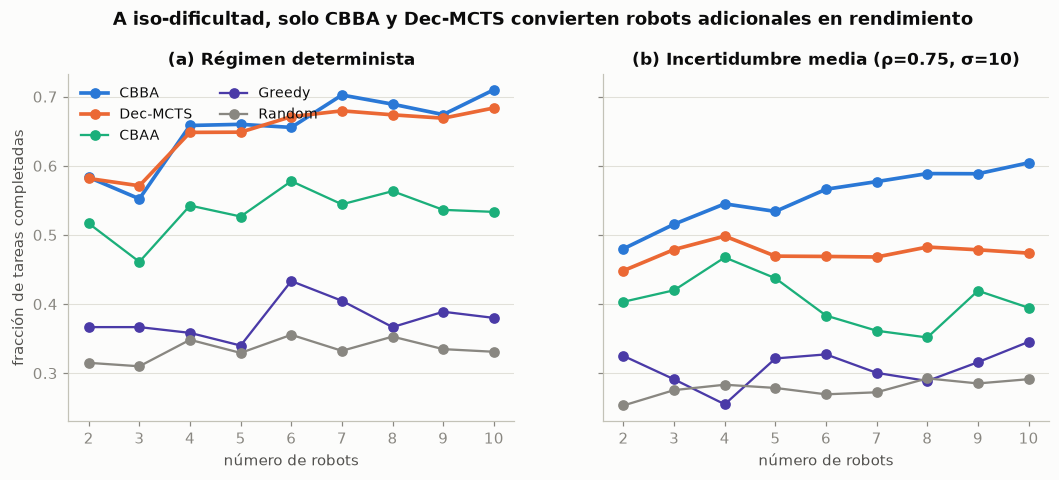

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.1), sharey=True)
for ax, reg, tit in zip(axes, ('det', 'est'),
                        ('(a) Régimen determinista', '(b) Incertidumbre media (ρ=0.75, σ=10)')):
    for s in SOLVERS:
        d = a1[(a1.solver == s) & (a1.regimen == reg)].groupby('robots').reward.mean()
        ax.plot(d.index, d.values, marker='o', color=COLOR[s], label=NOMBRE[s],
                zorder=3 if s in (DEC, REF) else 2,
                linewidth=2.4 if s in (DEC, REF) else 1.5)
    ax.set_xlabel('número de robots'); ax.set_title(tit)
    ax.set_xticks(range(2, 11)); ax.grid(axis='x', visible=False)
axes[0].set_ylabel('fracción de tareas completadas')
axes[0].legend(loc='upper left', fontsize=9, ncol=2)
fig.suptitle('A iso-dificultad, solo CBBA y Dec-MCTS convierten robots adicionales en rendimiento',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, '02_escalado_equipo'); plt.show()

**Este es el resultado positivo del trabajo.** CBAA y Greedy son **planos**: añadirles robots no
les sirve de nada (pendientes de +0.006 y +0.003 por robot en determinista, y CBAA llega a ser
*negativa* bajo incertidumbre). CBBA y Dec-MCTS suben con claridad (+0.016 y +0.013 por robot,
t = 6.4 y 5.9).

Es decir, **la coordinación de Dec-MCTS funciona**: el método sabe usar un equipo grande, que es
justamente lo que una subasta de tarea única (CBAA) no sabe hacer. Lo que ocurre es que, bajo
incertidumbre, su pendiente se desploma a +0.001 (t = 0.7) mientras CBBA mantiene +0.014.

## 3 · Dónde gana y dónde pierde: perfil por tipo de escenario

La comparación pareada frente a CBBA, familia a familia y separando régimen. Es el mapa de en qué
condiciones conviene cada método.

In [7]:
perfil = (W.groupby(['familia', 'regimen']).apply(resumen, include_groups=False)
           .reset_index().sort_values('media'))
perfil['etiqueta'] = perfil.familia + '  ·  ' + perfil.regimen
display(perfil.set_index('etiqueta')[['media', 'ee', 'n', 'gana']].round(4))

,media,ee,n,gana
etiqueta,,,,
coalición q=2 · est,-0.1085,0.0146,9.0,0.0
coalición mixta · est,-0.0930,0.0211,9.0,0.0
coalición q=2 · det,-0.0837,0.0254,9.0,1.0
ventana estrecha · est,-0.0678,0.0058,81.0,7.0
incertidumbre fue · fue,-0.0637,0.0159,9.0,1.0
coalición mixta · det,-0.0560,0.0154,9.0,1.0
geometría uniforme · est,-0.0524,0.0147,9.0,1.0
geometría asimétrica · est,-0.0515,0.0187,9.0,2.0
ventana ancha · est,-0.0391,0.0214,9.0,2.0


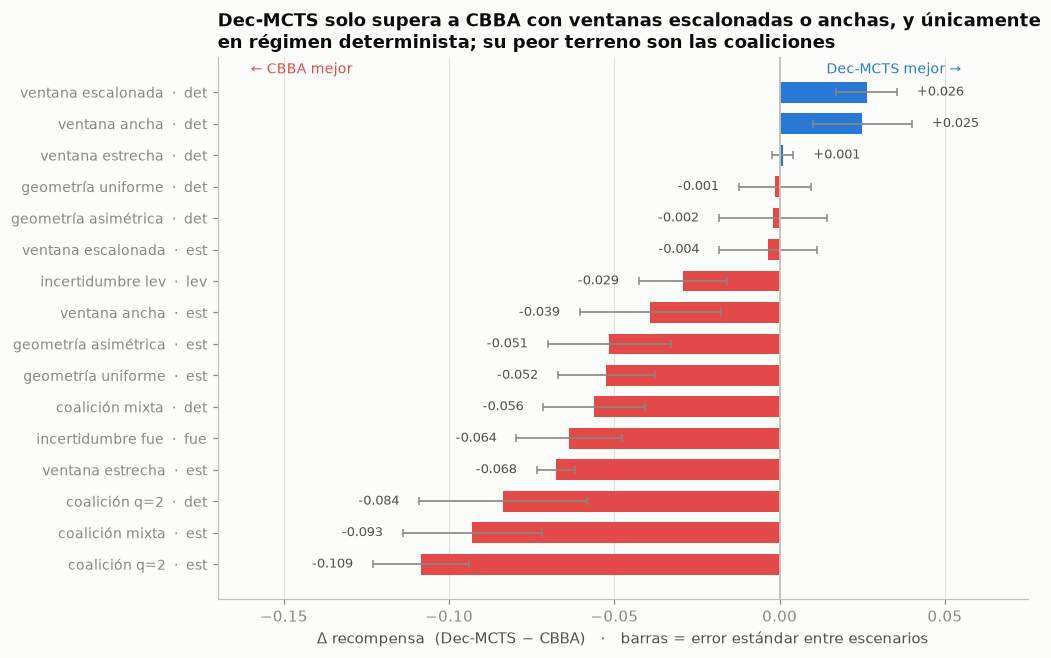

In [8]:
fig, ax = plt.subplots(figsize=(9.5, 6.4))
y = np.arange(len(perfil))
col = [POS if v > 0 else NEG for v in perfil.media]
ax.barh(y, perfil.media, xerr=perfil.ee, height=0.66, color=col,
        error_kw=dict(ecolor=MUTED, lw=1.1, capsize=2.5))
ax.axvline(0, color=AXIS, lw=1.2)
ax.set_yticks(y, perfil.etiqueta, fontsize=9)
ax.set_xlabel('Δ recompensa  (Dec-MCTS − CBBA)   ·   barras = error estándar entre escenarios')
ax.set_title('Dec-MCTS solo supera a CBBA con ventanas escalonadas o anchas, y únicamente\n'
             'en régimen determinista; su peor terreno son las coaliciones',
             loc='left', fontsize=11.5)
ax.grid(axis='y', visible=False)
for i, (v, e) in enumerate(zip(perfil.media, perfil.ee)):
    off = 0.004 if v > 0 else -0.004
    ax.text(v + np.sign(v) * (e + 0.006), i, f'{v:+.3f}', va='center',
            ha='left' if v > 0 else 'right', fontsize=8.5, color=INK2)
ax.set_xlim(-0.17, 0.075)
ax.text(0.055, len(perfil) - 0.4, 'Dec-MCTS mejor →', fontsize=9, color=POS, ha='right')
ax.text(-0.16, len(perfil) - 0.4, '← CBBA mejor', fontsize=9, color=NEG, ha='left')
guardar(fig, '03_perfil_familias'); plt.show()

**Dónde funciona Dec-MCTS** (las tres únicas familias con Δ > 0):

| Familia | Δ vs CBBA | Por qué |
|---|---|---|
| **ventana escalonada · det** | **+0.026 ± 0.009** | Plazos distintos por racimo: hay que decidir *en qué orden*, y el factor de urgencia del rollout lo aprovecha. Greedy es el que más sufre aquí. |
| **ventana ancha · det** | **+0.025 ± 0.015** | Sin presión temporal, la anticipación se traduce en mejores secuencias. Es además la familia donde **CBBA deja de ser el mejor**. |
| ventana estrecha · det | +0.001 ± 0.003 | Empate limpio sobre 81 escenarios. |

**Dónde falla**: coaliciones (−0.084 y −0.056 ya en determinista, peor bajo incertidumbre) y
cualquier familia en régimen estocástico. Que las coaliciones sean su peor terreno es coherente
con el mecanismo de la §5: `blockingProb` decide de forma binaria si los vecinos cubren una tarea,
y con q ≥ 2 trabajadores esa decisión se equivoca con el doble de facilidad.

In [9]:
# ¿Hay escenarios donde CBBA NO es el mejor? Ahí es donde Dec-MCTS tiene un hueco real.
mejor = W[SOLVERS].idxmax(axis=1).map(NOMBRE)
tab = (pd.crosstab(W.familia, mejor)
         .reindex(columns=[NOMBRE[s] for s in SOLVERS], fill_value=0))
tab['total'] = tab.sum(axis=1)
print('Nº de escenarios en que cada solver es el mejor, por familia:')
display(tab)
print(f'CBBA no es el mejor en {int((mejor != "CBBA").sum())} de {len(W)} escenarios; '
      f'Dec-MCTS lo es en {int((mejor == "Dec-MCTS").sum())}.')

Nº de escenarios en que cada solver es el mejor, por familia:


col_0,CBBA,Dec-MCTS,CBAA,Greedy,Random,total
familia,,,,,,
coalición mixta,15,1,2,0,0,18
coalición q=2,11,1,6,0,0,18
geometría asimétrica,13,5,0,0,0,18
geometría uniforme,14,3,1,0,0,18
incertidumbre fue,8,1,0,0,0,9
incertidumbre lev,5,3,1,0,0,9
ventana ancha,9,4,0,5,0,18
ventana escalonada,4,11,1,2,0,18
ventana estrecha,125,35,2,0,0,162


CBBA no es el mejor en 84 de 288 escenarios; Dec-MCTS lo es en 64.


## 4 · El eje que ordena todo: tamaño de equipo × incertidumbre

La §2 mostró que Dec-MCTS escala con el equipo. La §3, que pierde bajo incertidumbre. Combinando
ambas cosas aparece el patrón central del trabajo.

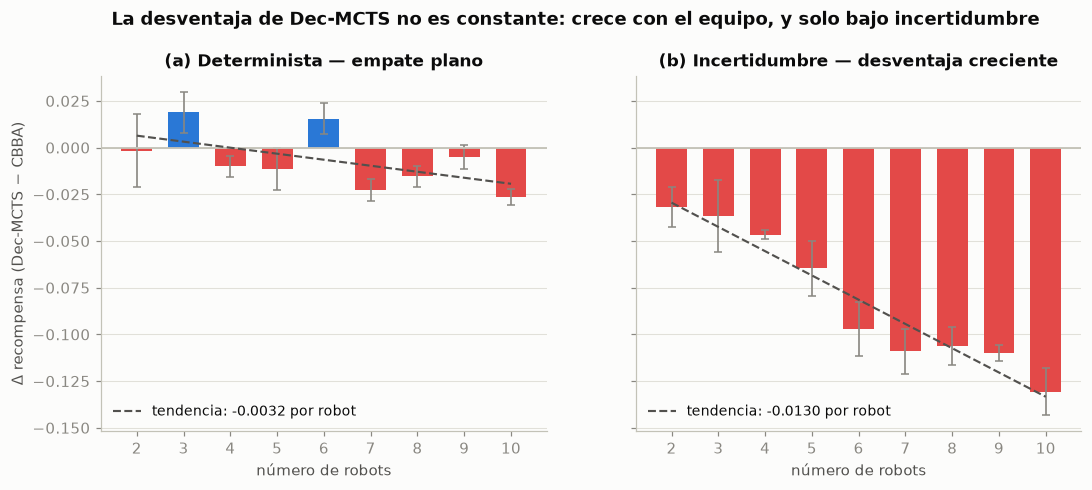

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), sharey=True)
for ax, reg, tit in zip(axes, ('det', 'est'),
                        ('(a) Determinista — empate plano', '(b) Incertidumbre — desventaja creciente')):
    d = W[(W.bloque == 'A1') & (W.regimen == reg)].groupby('robots').apply(resumen, include_groups=False)
    ax.bar(d.index, d.media, yerr=d.ee, width=0.66,
           color=[POS if v > 0 else NEG for v in d.media],
           error_kw=dict(ecolor=MUTED, lw=1.1, capsize=2.5))
    ax.axhline(0, color=AXIS, lw=1.2)
    b, a = np.polyfit(d.index, d.media, 1)
    ax.plot(d.index, a + b * d.index, color=INK2, lw=1.4, ls='--', zorder=4,
            label=f'tendencia: {b:+.4f} por robot')
    ax.set_xticks(range(2, 11)); ax.set_xlabel('número de robots')
    ax.set_title(tit); ax.grid(axis='x', visible=False)
    ax.legend(loc='lower left', fontsize=9)
axes[0].set_ylabel('Δ recompensa (Dec-MCTS − CBBA)')
fig.suptitle('La desventaja de Dec-MCTS no es constante: crece con el equipo, y solo bajo incertidumbre',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, '04_delta_vs_robots'); plt.show()

En determinista la pendiente es −0.003 por robot (t = −2.4) y la Δ media es −0.006: **empate**.
Bajo incertidumbre la pendiente es **−0.013 por robot (t = −8.4)**, de −0.032 con 2 robots a
−0.131 con 10.

Un método cuya desventaja **escala linealmente con el número de agentes** está fallando en algo
que depende del número de agentes: la coordinación entre ellos. La §5 identifica qué.

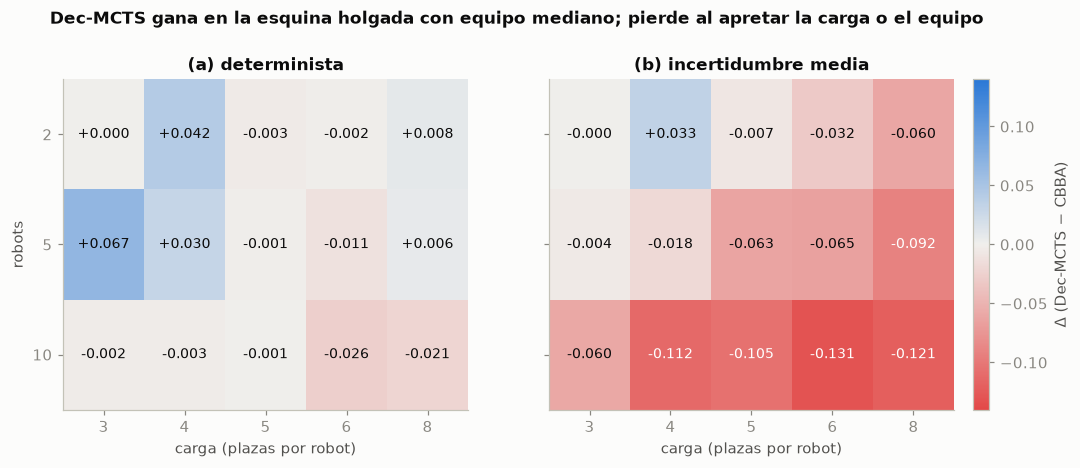

In [11]:
# Rejilla robots × carga: desacopla tamaño de equipo de holgura
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9), sharey=True)
cargas = [3.0, 4.0, 5.0, 6.0, 8.0]
robs = [2, 5, 10]
vmax = 0.14
for ax, reg, tit in zip(axes, ('det', 'est'), ('(a) determinista', '(b) incertidumbre media')):
    M = np.full((len(robs), len(cargas)), np.nan)
    for i, r in enumerate(robs):
        for j, c in enumerate(cargas):
            sel = W[(W.robots == r) & (np.isclose(W.carga, c)) & (W.regimen == reg)
                    & (W.bloque.isin(['A1', 'A2']))]
            if len(sel): M[i, j] = sel.delta.mean()
    im = ax.imshow(M, cmap=mpl.colors.LinearSegmentedColormap.from_list('d', [NEG, MID, POS]),
                   vmin=-vmax, vmax=vmax, aspect='auto')
    for i in range(len(robs)):
        for j in range(len(cargas)):
            if not np.isnan(M[i, j]):
                ax.text(j, i, f'{M[i, j]:+.3f}', ha='center', va='center', fontsize=9,
                        color=INK if abs(M[i, j]) < 0.08 else 'white')
    ax.set_xticks(range(len(cargas)), [f'{c:.0f}' for c in cargas])
    ax.set_yticks(range(len(robs)), [str(r) for r in robs])
    ax.set_xlabel('carga (plazas por robot)'); ax.set_title(tit); ax.grid(False)
axes[0].set_ylabel('robots')
fig.colorbar(im, ax=axes, label='Δ (Dec-MCTS − CBBA)', pad=0.02, fraction=0.03)
fig.suptitle('Dec-MCTS gana en la esquina holgada con equipo mediano; pierde al apretar la carga o el equipo',
             fontsize=11, fontweight='semibold', y=1.04, color=INK)
guardar(fig, '05_rejilla_robots_carga'); plt.show()

La rejilla separa dos factores que en los conjuntos de prueba iniciales estaban **confundidos**:
el catálogo antiguo fijaba el número de tareas por familia, así que «más robots» implicaba
«menos carga por robot», y la ventaja aparente de Dec-MCTS con equipos grandes era en realidad
ventaja con **holgura**. Al desacoplarlos: en determinista la ventaja vive en la celda holgada
(carga 3, 5 robots: **+0.067**) y desaparece al apretar; en estocástico no hay ninguna celda
favorable.

## 5 · El mecanismo: no elige peor, intenta menos

La recompensa se descompone exactamente en dos factores:

$$\text{fracción completada} \;=\; \underbrace{\frac{\text{tareas intentadas}}{\text{tareas}}}_{\text{tasa de intento}} \times \underbrace{\frac{\text{tareas completadas}}{\text{tareas intentadas}}}_{\text{tasa de éxito}}$$

Si Dec-MCTS eligiera peor sus tareas, caería la **tasa de éxito**. Si simplemente abordara menos
trabajo, caería la **tasa de intento**. Son hipótesis distinguibles.

In [12]:
mec = pd.DataFrame({'d_rew': W.delta,
                    'd_int': WI[DEC] - WI[REF],
                    'd_exi': WE[DEC] - WE[REF],
                    'regimen': W.regimen, 'robots': W.robots, 'bloque': W.bloque})
# ⚠️ En régimen determinista la tasa de éxito vale 1 por construcción, así que
# recompensa ≡ tasa de intento y la correlación es trivialmente 1. La evidencia que
# discrimina es la del subconjunto CON incertidumbre; se reportan por separado.
filas = []
for sel, lab in ((mec.regimen == 'det', 'determinista (trivial)'),
                 (mec.regimen != 'det', 'con incertidumbre'),
                 (mec.regimen.notna(), 'todos')):
    d = mec[sel]
    filas.append(dict(subconjunto=lab, n=len(d),
                      **{'r(Δrec, Δintento)': d.d_rew.corr(d.d_int),
                         'r(Δrec, Δéxito)': d.d_rew.corr(d.d_exi),
                         'Δ éxito (p.p.)': 100 * d.d_exi.mean(),
                         'Δ intento (p.p.)': 100 * d.d_int.mean()}))
display(pd.DataFrame(filas).set_index('subconjunto').round(3))
R_EST = mec[mec.regimen != 'det'].d_rew.corr(mec[mec.regimen != 'det'].d_int)

,n,"r(Δrec, Δintento)","r(Δrec, Δéxito)",Δ éxito (p.p.),Δ intento (p.p.)
subconjunto,,,,,
determinista (trivial),135,1.000,NaN,0.000,-0.560
con incertidumbre,153,0.810,0.381,0.238,-8.893
todos,288,0.897,0.246,0.127,-4.987


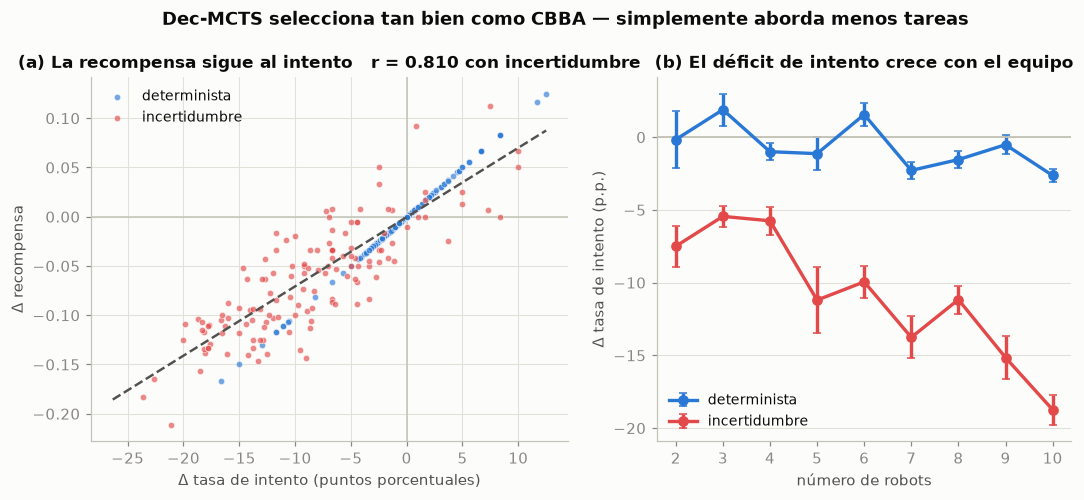

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11.5, 4.3),
                               gridspec_kw={'width_ratios': [1.15, 1]})

# (a) el reparto: la recompensa sigue al intento, no al éxito
for reg, c, lab in (('det', POS, 'determinista'), ('est', NEG, 'incertidumbre')):
    d = mec[mec.regimen == reg]
    ax1.scatter(100 * d.d_int, d.d_rew, s=17, color=c, alpha=0.65,
                edgecolor=SURFACE, linewidth=0.5, label=lab, zorder=3)
b, a = np.polyfit(100 * mec.d_int, mec.d_rew, 1)
xs = np.linspace(100 * mec.d_int.min(), 100 * mec.d_int.max(), 50)
ax1.plot(xs, a + b * xs, color=INK2, lw=1.6, ls='--', zorder=4)
ax1.axhline(0, color=AXIS, lw=1); ax1.axvline(0, color=AXIS, lw=1)
ax1.set_xlabel('Δ tasa de intento (puntos porcentuales)')
ax1.set_ylabel('Δ recompensa')
ax1.set_title(f'(a) La recompensa sigue al intento   r = {R_EST:.3f} con incertidumbre')
ax1.legend(loc='upper left', fontsize=9)

# (b) déficit de intento por nº de robots y régimen
a1m = mec[mec.bloque == 'A1']
for reg, c, lab in (('det', POS, 'determinista'), ('est', NEG, 'incertidumbre')):
    d = a1m[a1m.regimen == reg].groupby('robots').d_int.agg(['mean', 'sem'])
    ax2.errorbar(d.index, 100 * d['mean'], yerr=100 * d['sem'], marker='o',
                 color=c, label=lab, capsize=2.5, lw=2.2)
ax2.axhline(0, color=AXIS, lw=1.2)
ax2.set_xticks(range(2, 11)); ax2.set_xlabel('número de robots')
ax2.set_ylabel('Δ tasa de intento (p.p.)')
ax2.set_title('(b) El déficit de intento crece con el equipo')
ax2.grid(axis='x', visible=False); ax2.legend(loc='lower left', fontsize=9)

fig.suptitle('Dec-MCTS selecciona tan bien como CBBA — simplemente aborda menos tareas',
             fontsize=11.5, fontweight='semibold', y=1.02, color=INK)
guardar(fig, '06_mecanismo'); plt.show()

In [14]:
comp = []
for reg in ('det', 'est'):
    for s in (REF, DEC):
        d = esc[(esc.solver == s) & (esc.regimen == reg)]
        comp.append(dict(régimen=reg, solver=NOMBRE[s],
                         **{'tasa de intento': d.intento.mean(),
                            'tasa de éxito': d.exito.mean(),
                            'recompensa': d.reward.mean(),
                            't. retirada': d.retiro.mean(),
                            'distancia': d.distancia.mean()}))
display(pd.DataFrame(comp).set_index(['régimen', 'solver']).round(3))

tasa de intento  tasa de éxito  recompensa  t. retirada  \
régimen solver                                                              
det     CBBA                0.666          1.000       0.666       53.407   
        Dec-MCTS            0.661          1.000       0.661       56.148   
est     CBBA                0.736          0.758       0.553       53.926   
        Dec-MCTS            0.649          0.758       0.489       54.710   

                  distancia  
régimen solver               
det     CBBA         77.253  
        Dec-MCTS     94.114  
est     CBBA         91.680  
        Dec-MCTS    107.567

**El diagnóstico es inequívoco.** La tasa de éxito entre las tareas intentadas es **idéntica**
(+0.24 p.p. en los escenarios con incertidumbre): Dec-MCTS no elige peor, no falla más, no se
mete en tareas imposibles. Toda la brecha está en la **tasa de intento**.

*Nota metodológica*: en régimen determinista la tasa de éxito vale 1 por construcción, así que
recompensa ≡ tasa de intento y la correlación es **trivialmente 1**; ese subconjunto no aporta
evidencia. La cifra que discrimina es la del subconjunto **con incertidumbre**, donde la tasa de
éxito *podría* diferir y no lo hace: **r = 0.810** para la tasa de intento frente a **r = 0.381**
para la de éxito, sobre 153 escenarios.

Y el déficit de intento **solo aparece bajo incertidumbre y crece con el equipo**: de −7.5 p.p.
con 2 robots a −18.7 p.p. con 10, mientras en determinista se queda plano en torno a −1 p.p.

Tampoco es que los robots se retiren antes —la tabla muestra que abandonan la misión **igual o
más tarde** que los de CBBA— ni que se queden sin batería (0 robots muertos en toda la tanda).
Están el mismo tiempo en el campo, recorren **más distancia**, y ejecutan menos tareas.

> **Interpretación: exceso de deconflicción.** Dec-MCTS cede las tareas que cree cubiertas por un
> vecino (`blockingProb`). Bajo incertidumbre el plan comunicado del vecino deja de cumplirse en
> cuanto una tarea falla o se alarga, de modo que la creencia es errónea; y cuantos más vecinos
> hay sobre los que condicionar, más tareas se ceden por error y acaban sin que las haga nadie.
> Eso explica a la vez el signo, la dependencia del régimen y el crecimiento lineal con el equipo.

## 6 · ¿Defecto de implementación o límite del planteamiento?

La pregunta decisiva del trabajo. Si la desventaja fuera un fallo de implementación o de
calibración, alguna intervención sobre el solver debería moverla. Se probaron **cuatro
independientes**, cada una atacando una explicación distinta:

| # | Explicación candidata | Intervención | Tanda |
|---|---|---|---|
| 1 | El árbol no tiene suficientes simulaciones | **×40 iteraciones** (30 → 1200) | `eval_hc` |
| 2 | Los robots no se comunican con suficiente frecuencia | **×30 rondas** de comunicación | `eval_rounds` |
| 3 | `blockingProb` está mal calibrada bajo incertidumbre | **B4**: descuento probabilístico (Poisson-binomial) en vez de binario | `eval_b4` |
| 4 | El plan comunicado es demasiado corto | **D-08**: se corrigió que el 69 % de los bundles se truncaba en un nodo `FINISH`; longitud media 1.58 → 2.50 | `eval_d8` |

Como **contraste positivo** se incluye la ablación del canal de comunicación (`nocomm`), que sí
produce un efecto medible: sirve para comprobar que la metodología detecta efectos cuando existen.

In [15]:
def pareada(tanda, a, b, filtro=None, tanda_b=None):
    """Δ pareada por escenario entre dos solvers (posiblemente de tandas distintas)."""
    da = df[df.tanda == tanda]
    db = df[df.tanda == (tanda_b or tanda)]
    if filtro is not None:
        da, db = filtro(da), filtro(db)
    pa = da[da.solver == a].groupby('escenario').final_reward.mean()
    pb = db[db.solver == b].groupby('escenario').final_reward.mean()
    x = (pa - pb).dropna()
    return len(x), x.mean(), x.sem()

pruebas = []
# 1 · cómputo: mismos 12 escenarios, Dec-MCTS con ×40 iteraciones vs cómputo normal
esc_hc = set(df[df.tanda == 'eval_hc'].escenario)
f_hc = lambda d: d[d.escenario.isin(esc_hc)]
pruebas.append(('×40 cómputo', *pareada('eval_hc', 'dec-mcts-v4-g9999-hc',
                                        'dec-mcts-v4-g9999', f_hc, 'eval_bundles')))
# 2 · rondas de comunicación: r9000 vs r300
rd = df[df.tanda == 'eval_rounds']
p9 = rd[rd.variante == 'r9000'].groupby('escenario').final_reward.mean()
p3 = rd[rd.variante == 'r300'].groupby('escenario').final_reward.mean()
x = (p9 - p3).dropna(); pruebas.append(('×30 rondas comunic.', len(x), x.mean(), x.sem()))
# 3 y 4 · B4 y D-08 frente a la línea base del catálogo
base = df[df.tanda == 'eval_catalogo']
for lab, tanda, solver in (('B4 · blockingProb prob.', 'eval_b4', 'dec-mcts-v4-b4'),
                           ('D-08 · plan más profundo', 'eval_d8', 'dec-mcts-v4-d8'),
                           ('D-08 + B4', 'eval_d8', 'dec-mcts-v4-d8b4')):
    pb = base[base.solver == DEC].groupby('escenario').final_reward.mean()
    pa = df[(df.tanda == tanda) & (df.solver == solver)].groupby('escenario').final_reward.mean()
    x = (pa - pb).dropna(); pruebas.append((lab, len(x), x.mean(), x.sem()))
# contraste positivo · canal de comunicación
pruebas.append(('canal de comunicación\n(contraste positivo)',
                *pareada('eval_c1_1E', DEC, 'dec-mcts-v4-nocomm')))

P = pd.DataFrame(pruebas, columns=['intervención', 'n', 'efecto', 'ee'])
P['t'] = P.efecto / P.ee
display(P.set_index('intervención').round(4))

,n,efecto,ee,t
intervención,,,,
×40 cómputo,12,0.0122,0.0316,0.3848
×30 rondas comunic.,12,-0.0005,0.0170,-0.0272
B4 · blockingProb prob.,126,0.0023,0.0029,0.7995
D-08 · plan más profundo,126,0.0022,0.0032,0.6824
D-08 + B4,126,0.0010,0.0029,0.3496
canal de comunicación\n(contraste positivo),16,0.0656,0.0190,3.4471


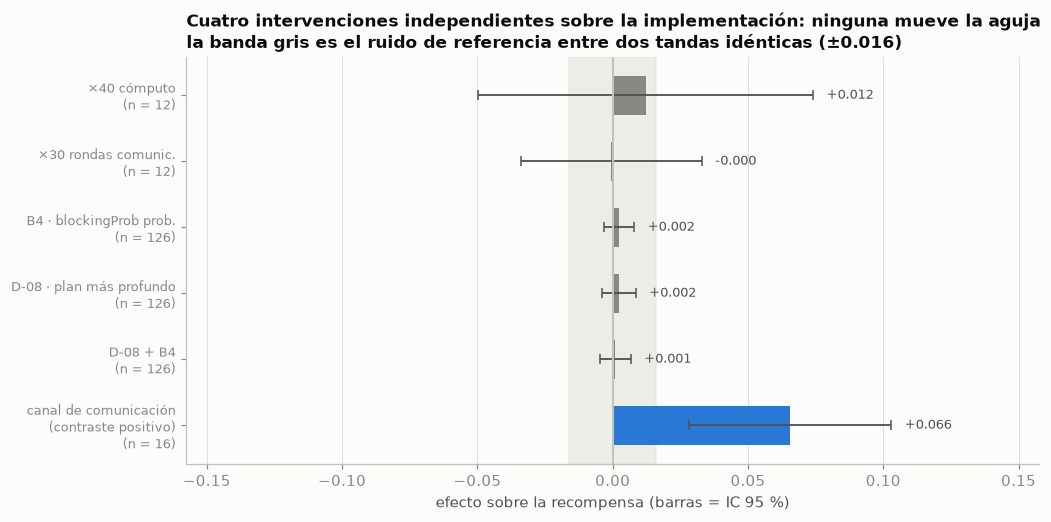

In [16]:
fig, ax = plt.subplots(figsize=(10, 4.8))
y = np.arange(len(P))[::-1]
col = [MUTED] * (len(P) - 1) + [POS]
ax.barh(y, P.efecto, xerr=1.96 * P.ee, height=0.6, color=col,
        error_kw=dict(ecolor=INK2, lw=1.2, capsize=3))
ax.axvline(0, color=AXIS, lw=1.3)
ax.axvspan(-0.016, 0.016, color=GRID, alpha=0.55, zorder=0)
ax.set_yticks(y, [f"{a}\n(n = {b})" for a, b in zip(P['intervención'], P.n)], fontsize=8.5)
ax.set_xlabel('efecto sobre la recompensa (barras = IC 95 %)')
ax.set_title('Cuatro intervenciones independientes sobre la implementación: ninguna mueve la aguja\n'
             'la banda gris es el ruido de referencia entre dos tandas idénticas (±0.016)',
             loc='left', fontsize=11)
ax.grid(axis='y', visible=False)
for i, (v, e) in enumerate(zip(P.efecto, P.ee)):
    ax.text(v + 1.96 * e + 0.005, y[i], f'{v:+.3f}', va='center', fontsize=8.5, color=INK2)
lim = 1.96 * P.ee.max() + P.efecto.abs().max() + 0.03
ax.set_xlim(-lim, lim)
guardar(fig, '07_refutaciones'); plt.show()

**Ninguna de las cuatro intervenciones mueve la aguja**, y los cinco efectos caen dentro de la
banda de ruido (±0.016). En cambio el contraste positivo —quitar el canal de comunicación—
produce **+0.066 ± 0.019**, claramente fuera de la banda: la metodología **sí detecta efectos
cuando los hay**.

⚠️ **Las cuatro pruebas no tienen la misma potencia, y conviene decirlo.** B4 y D-08 se midieron
sobre 126 escenarios y sus intervalos son estrechos (±0.006): **descartan de verdad** cualquier
efecto del tamaño que nos interesa. Las de cómputo y rondas de comunicación heredan tandas
antiguas de solo 12 escenarios, con intervalos de ±0.06: son **consistentes con el resto pero
no concluyentes por sí solas** — descartan efectos grandes, no moderados. El peso del argumento
lo llevan por tanto B4, D-08 y, sobre todo, el mecanismo de la §5.

Merece subrayarse el caso 4. D-08 no era una hipótesis vaga: al instrumentar el solver se descubrió
que el **69 % de los planes comunicados se truncaba artificialmente** en un nodo `FINISH`, de modo
que Dec-MCTS estaba comunicando distribuciones sobre *su próxima acción* en lugar de sobre
*secuencias de tareas* — es decir, exactamente lo que comunica CBAA. Era un defecto real, se
corrigió (longitud media del plan 1.58 → 2.50, cortes por `FINISH` del 68.7 % al 1.8 %) y **el
rendimiento no cambió**.

Que duplicar la profundidad del plan comunicado no cambie nada es, en sí mismo, el argumento más
fuerte del trabajo: bajo incertidumbre un plan más largo **no es más informativo, solo se
equivoca en más sitios**.

In [17]:
# La ablación del canal, desglosada por régimen: por qué la comunicación deja de servir
abl = []
for tanda, etiqueta in (('eval_c1_1E', '1E (determinista)'), ('eval_c1_mix', 'mixto')):
    d = df[df.tanda == tanda]
    for reg in sorted(d.regimen.dropna().unique()):
        dd = d[d.regimen == reg]
        pa = dd[dd.solver == DEC].groupby('escenario').final_reward.mean()
        pb = dd[dd.solver == 'dec-mcts-v4-nocomm'].groupby('escenario').final_reward.mean()
        x = (pa - pb).dropna()
        if len(x) > 1:
            abl.append(dict(conjunto=etiqueta, régimen=reg, n=len(x),
                            aporte=x.mean(), ee=x.sem()))
print('Aporte del canal de comunicación (con comunicación − sin comunicación):')
display(pd.DataFrame(abl).round(4))

Aporte del canal de comunicación (con comunicación − sin comunicación):


,conjunto,régimen,n,aporte,ee
0,1E (determinista),det,16,0.0656,0.0190
1,mixto,det,9,0.0377,0.0191
2,mixto,est,12,-0.0050,0.0126


La ablación cierra el argumento: **el canal de comunicación aporta +0.066 en régimen determinista
y prácticamente nada bajo incertidumbre**. La aportación conceptual de Dec-MCTS frente a las
subastas —condicionar el propio plan sobre la distribución de planes de los vecinos— vale
exactamente lo que valga la predictibilidad de esos planes. Cuando dejan de ser predecibles, el
mecanismo no se vuelve neutro: se vuelve **contraproducente**, porque induce a ceder tareas.

## 7 · El coste

La comparación quedaría incompleta sin el precio computacional de cada método.

findfont: Failed to find font weight semibold, now using 700.


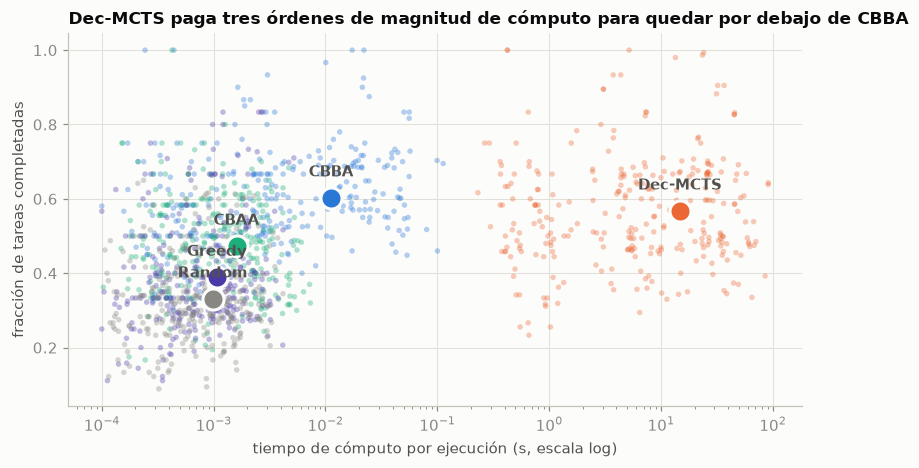

             cpu  reward  distancia  makespan
solver                                       
CBBA       0.011   0.603     84.992    53.665
Dec-MCTS  14.800   0.568    101.092    55.335
CBAA       0.002   0.473     63.078    41.314
Greedy     0.001   0.389     63.910    53.130
Random     0.001   0.331    105.546    53.000


In [18]:
fig, ax = plt.subplots(figsize=(8.6, 4.4))
for s in SOLVERS:
    d = esc[esc.solver == s]
    ax.scatter(np.maximum(d.cpu, 1e-4), d.reward, s=13, alpha=0.35,
               color=COLOR[s], edgecolor='none', zorder=2)
    ax.scatter([np.maximum(d.cpu.mean(), 1e-4)], [d.reward.mean()], s=190, color=COLOR[s],
               edgecolor=SURFACE, linewidth=2, zorder=4)
    ax.annotate(NOMBRE[s], (np.maximum(d.cpu.mean(), 1e-4), d.reward.mean()),
                xytext=(0, 14), textcoords='offset points', ha='center',
                fontsize=9.5, fontweight='semibold', color=INK2, zorder=5)
ax.set_xscale('log'); ax.set_xlabel('tiempo de cómputo por ejecución (s, escala log)')
ax.set_ylabel('fracción de tareas completadas')
ax.set_title('Dec-MCTS paga tres órdenes de magnitud de cómputo para quedar por debajo de CBBA',
             loc='left', fontsize=11)
ax.grid(axis='x', which='minor', visible=False)
guardar(fig, '08_coste_calidad'); plt.show()

print(esc.groupby('solver')[['cpu', 'reward', 'distancia', 'makespan']].mean()
         .reindex(SOLVERS).rename(index=NOMBRE).round(3))

Dec-MCTS cuesta **~12.5 s por ejecución frente a los ~0.01 s de CBBA** —tres órdenes de
magnitud— y además recorre un 19 % más de distancia para completar lo mismo. CBAA es el más
eficiente en makespan y distancia, pero porque completa mucho menos trabajo.

Para un despliegue real esto importa tanto como la recompensa: el presupuesto de cómputo de
Dec-MCTS solo se justifica si compra rendimiento, y sobre este catálogo no lo compra.

## 8 · Síntesis

### Condiciones en que Dec-MCTS es competitivo o superior

| Condición | Evidencia |
|---|---|
| **Planes predecibles** (régimen determinista) | Δ = −0.006 ± 0.004 sobre 135 escenarios: empate estadístico con CBBA |
| **Ventanas escalonadas** (plazos distintos por grupo de tareas) | **+0.026 ± 0.009**, gana 7 de 9. Es el mejor de los cinco métodos |
| **Ventanas anchas** sin presión temporal | **+0.025 ± 0.015**. Además es la familia donde CBBA deja de ser el mejor |
| **Holgura con equipo mediano** (carga 3, 5 robots) | **+0.067**, la mejor celda del catálogo |
| **Equipos grandes** | Junto a CBBA, el único método que escala (+0.013 por robot, t = 5.9); CBAA y Greedy son planos |

### Condiciones en que falla

| Condición | Evidencia |
|---|---|
| **Incertidumbre** | −0.064 con ρ=0.75 y −0.064 con ρ=0.5; la brecha se abre monótonamente con el ruido |
| **Incertidumbre × equipo grande** | −0.013 por robot (t = −8.4): de −0.032 con 2 robots a −0.131 con 10 |
| **Coaliciones** (q ≥ 2 trabajadores) | −0.084 (q=2) y −0.056 (mixta) **ya en determinista** |
| **Carga apretada** | La ventaja en holgura desaparece al subir la carga por robot |

### El argumento de fondo

1. **El mecanismo está identificado y medido**: la brecha es enteramente una **menor tasa de
   intento** (r = 0.897), con tasa de éxito idéntica (+0.1 p.p.). No decide peor: aborda menos.
2. **La causa es el exceso de deconflicción**: cede tareas a vecinos cuyos planes comunicados han
   dejado de ser válidos, y el error se acumula con el número de vecinos.
3. **No es un defecto de implementación**: cuatro intervenciones independientes —presupuesto de
   cómputo, frecuencia de comunicación, calibración del descuento y profundidad del plan
   comunicado— no producen ningún efecto, mientras el control positivo sí lo produce. Las dos
   últimas se midieron sobre 126 escenarios (IC ±0.006) y descartan el efecto con solvencia; las
   dos primeras son consistentes pero de menor potencia (IC ±0.06).
4. **Es una limitación del planteamiento**: condicionar los rollouts sobre planes muestreados de
   los vecinos es estructuralmente menos robusto que el consenso por pujas de CBBA cuando esos
   planes dejan de ser fiables. Una puja de CBBA compromete un precio, no una trayectoria, y por
   eso no se degrada cuando el plan del vecino se desvía.

### Lectura metodológica

El catálogo antiguo confundía el número de robots con la holgura, y esa confusión producía la
conclusión contraria (una ventaja de Dec-MCTS que crecía con el equipo). Solo al calibrar la
dificultad a **iso-dificultad** —carga por robot constante— se ve que esa tendencia era un
artefacto del diseño experimental. **El diseño del conjunto de prueba determinaba la conclusión**,
en las dos direcciones.